<a href="https://colab.research.google.com/github/Seifallah3/MTA_Daily-Ridership/blob/main/Cleaning%26Analysis_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========================================================
# 1️⃣ Setup & Data Loading
# =========================================================

## 1.1 Import Libraries
Import necessary libraries for data analysis, manipulation, and visualization:

- `pandas` → For data manipulation and analysis (DataFrames)  
- `numpy` → For numerical operations (arrays, math functions)  
- `matplotlib.pyplot` → For creating static plots and charts  
- `matplotlib.dates` → For handling and formatting date axes in plots  
- `matplotlib.ticker` → For custom formatting of axis tick labels  
- `seaborn` → For advanced statistical visualization (built on matplotlib)  
- `pandas.tseries.holiday.USFederalHolidayCalendar` → For identifying US federal holidays  
- `itertools` → For creating all possible combinations of elements (used in pairwise plots)

In [ ]:
# Import necessary libraries for data analysis, manipulation, and visualization

import pandas as pd              # For data manipulation and analysis (DataFrames)
import numpy as np               # For numerical operations (arrays, math functions)
import matplotlib.pyplot as plt  # For creating static plots and charts
import matplotlib.dates as mdates # For handling and formatting date axes in plots
import matplotlib.ticker as mtick # For custom formatting of axis tick labels
import seaborn as sns            # For advanced statistical visualization (built on matplotlib)
from pandas.tseries.holiday import USFederalHolidayCalendar
                                 # For identifying US federal holidays
import itertools                 # For creating all possible combinations of elements (used in pairwise plots)

1.2 Load Dataset

Read the MTA Daily Ridership CSV file into a DataFrame:


In [ ]:
# Read the MTA daily ridership CSV file into a pandas DataFrame
# - Adjust the file path as needed to where the CSV is stored
df = pd.read_csv("/content/MTA_Daily_Ridership.csv")

# Display the first 5 rows to inspect the data and verify successful import
df.head()

,Date,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
0,2020-03-01,2212965,97,984908,99,86790,100,55825,59,19922,113,786960,98,1636,52
1,2020-03-02,5329915,96,2209066,99,321569,103,180701,66,30338,102,874619,95,17140,107
2,2020-03-03,5481103,98,2228608,99,319727,102,190648,69,32767,110,882175,96,17453,109
3,2020-03-04,5498809,99,2177165,97,311662,99,192689,70,34297,115,905558,98,17136,107
4,2020-03-05,5496453,99,2244515,100,307597,98,194386,70,33209,112,929298,101,17203,108


1.3 Inspect Column Data Types

Check the data types of all columns to plan conversions and analysis:

In [ ]:
# Display the data types of all columns in the DataFrame
# - Helps verify which columns are numeric, datetime, or object types
# - Useful for planning conversions or analysis
df.dtypes

,0
Date,object
Subways: Total Estimated Ridership,int64
Subways: % of Comparable Pre-Pandemic Day,int64
Buses: Total Estimated Ridership,int64
Buses: % of Comparable Pre-Pandemic Day,int64
LIRR: Total Estimated Ridership,int64
LIRR: % of Comparable Pre-Pandemic Day,int64
Metro-North: Total Estimated Ridership,int64
Metro-North: % of Comparable Pre-Pandemic Day,int64
Access-A-Ride: Total Scheduled Trips,int64


# =========================================================
# 2️⃣ Data Cleaning & Preliminary Analysis
# =========================================================

## 2.1 Convert 'Date' Column to Datetime
Converting the 'Date' column to datetime format allows for time-based operations such as filtering, grouping by quarter, or plotting over time.

In [ ]:
# Convert the 'Date' column to datetime format
# - This allows time-based operations like filtering, grouping by quarter, or plotting over time
df['Date'] = pd.to_datetime(df['Date'])

# Check the data types again to verify that 'Date' is now datetime
df.dtypes

,0
Date,datetime64[ns]
Subways: Total Estimated Ridership,int64
Subways: % of Comparable Pre-Pandemic Day,int64
Buses: Total Estimated Ridership,int64
Buses: % of Comparable Pre-Pandemic Day,int64
LIRR: Total Estimated Ridership,int64
LIRR: % of Comparable Pre-Pandemic Day,int64
Metro-North: Total Estimated Ridership,int64
Metro-North: % of Comparable Pre-Pandemic Day,int64
Access-A-Ride: Total Scheduled Trips,int64


## 2.2 Check for Missing Values
Identify any missing data in the dataset.

In [ ]:
# Check for missing values in each column of the DataFrame
# - isnull() returns True for NaN values
# - sum() counts the number of missing values per column
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print(missing_values)

Date                                                       0
Subways: Total Estimated Ridership                         0
Subways: % of Comparable Pre-Pandemic Day                  0
Buses: Total Estimated Ridership                           0
Buses: % of Comparable Pre-Pandemic Day                    0
LIRR: Total Estimated Ridership                            0
LIRR: % of Comparable Pre-Pandemic Day                     0
Metro-North: Total Estimated Ridership                     0
Metro-North: % of Comparable Pre-Pandemic Day              0
Access-A-Ride: Total Scheduled Trips                       0
Access-A-Ride: % of Comparable Pre-Pandemic Day            0
Bridges and Tunnels: Total Traffic                         0
Bridges and Tunnels: % of Comparable Pre-Pandemic Day      0
Staten Island Railway: Total Estimated Ridership           0
Staten Island Railway: % of Comparable Pre-Pandemic Day    0
dtype: int64


## 2.3 Check for Duplicate Rows
Detect rows that are exact duplicates to ensure data integrity.

In [ ]:
# Check for duplicate rows in the DataFrame
# - duplicated() returns True for rows that are exact duplicates of a previous row
# - sum() counts the total number of duplicate rows
duplicates = df.duplicated().sum()

# Print the total number of duplicate rows
print("Number of duplicates:", duplicates)

Number of duplicates: 0


## 2.4 Verify Complete Date Range
Ensure there are no missing dates in the dataset for consistent time-series analysis.

In [ ]:
# Find the minimum and maximum dates in the 'Date' column
min_date = df['Date'].min()
max_date = df['Date'].max()

# Create a complete date range from the earliest to the latest date, with daily frequency
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Identify any dates that are missing from the DataFrame
missing_dates = full_date_range.difference(df['Date'])

# Print whether there are any missing dates
if missing_dates.empty:
    print("There are no missing days in the 'Date' column.")
else:
    print(f"Missing dates in the 'Date' column: {missing_dates.tolist()}")

There are no missing days in the 'Date' column.


## 2.5 Identify Negative Ridership Values
Check for any negative values in ridership or traffic columns, which may indicate data errors.

In [ ]:
# Filter the DataFrame to find any rows where ridership or traffic values are negative
# - Checks each transport mode and Bridges & Tunnels traffic
# - Negative values might indicate data errors or missing values encoded incorrectly
filtered_df = df[
    (df['Subways: Total Estimated Ridership'] < 0) |
    (df['Buses: Total Estimated Ridership'] < 0) |
    (df['LIRR: Total Estimated Ridership'] < 0) |
    (df['Metro-North: Total Estimated Ridership'] < 0) |
    (df['Access-A-Ride: Total Scheduled Trips'] < 0) |
    (df['Bridges and Tunnels: Total Traffic'] < 0) |
    (df['Staten Island Railway: Total Estimated Ridership'] < 0)
]

# Display the filtered rows to inspect any negative or invalid values
print(filtered_df)

Empty DataFrame
Columns: [Date, Subways: Total Estimated Ridership, Subways: % of Comparable Pre-Pandemic Day, Buses: Total Estimated Ridership, Buses: % of Comparable Pre-Pandemic Day, LIRR: Total Estimated Ridership, LIRR: % of Comparable Pre-Pandemic Day, Metro-North: Total Estimated Ridership, Metro-North: % of Comparable Pre-Pandemic Day, Access-A-Ride: Total Scheduled Trips, Access-A-Ride: % of Comparable Pre-Pandemic Day, Bridges and Tunnels: Total Traffic, Bridges and Tunnels: % of Comparable Pre-Pandemic Day, Staten Island Railway: Total Estimated Ridership, Staten Island Railway: % of Comparable Pre-Pandemic Day]
Index: []


## 2.6 Rename Columns for Easier Analysis
Standardize column names to simplify later analysis and visualization:

- `*_total` → Total ridership/traffic  
- `*_pct` → Percentage of pre-pandemic levels  
- Bridges and Tunnels included as `bridges_total` and `bridges_pct`

In [ ]:
# Rename columns to shorter, standardized names for easier analysis
# - 'Total Estimated Ridership' columns → *_total
# - '% of Comparable Pre-Pandemic Day' columns → *_pct
# - Bridges and Tunnels also included as 'bridges_total' and 'bridges_pct'
df = df.rename(columns={
    "Date": "date",

    "Subways: Total Estimated Ridership": "subways_total",
    "Subways: % of Comparable Pre-Pandemic Day": "subways_pct",

    "Buses: Total Estimated Ridership": "buses_total",
    "Buses: % of Comparable Pre-Pandemic Day": "buses_pct",

    "LIRR: Total Estimated Ridership": "lirr_total",
    "LIRR: % of Comparable Pre-Pandemic Day": "lirr_pct",

    "Metro-North: Total Estimated Ridership": "metro_north_total",
    "Metro-North: % of Comparable Pre-Pandemic Day": "metro_north_pct",

    "Access-A-Ride: Total Scheduled Trips": "access_ride_total",
    "Access-A-Ride: % of Comparable Pre-Pandemic Day": "access_ride_pct",

    "Bridges and Tunnels: Total Traffic": "bridges_total",
    "Bridges and Tunnels: % of Comparable Pre-Pandemic Day": "bridges_pct",

    "Staten Island Railway: Total Estimated Ridership": "staten_total",
    "Staten Island Railway: % of Comparable Pre-Pandemic Day": "staten_pct"
})

# Print the updated column names to verify the renaming
print(df.columns)

Index(['date', 'subways_total', 'subways_pct', 'buses_total', 'buses_pct',
       'lirr_total', 'lirr_pct', 'metro_north_total', 'metro_north_pct',
       'access_ride_total', 'access_ride_pct', 'bridges_total', 'bridges_pct',
       'staten_total', 'staten_pct'],
      dtype='object')


In [ ]:
df.head()

,date,subways_total,subways_pct,buses_total,buses_pct,lirr_total,lirr_pct,metro_north_total,metro_north_pct,access_ride_total,access_ride_pct,bridges_total,bridges_pct,staten_total,staten_pct
0,2020-03-01,2212965,97,984908,99,86790,100,55825,59,19922,113,786960,98,1636,52
1,2020-03-02,5329915,96,2209066,99,321569,103,180701,66,30338,102,874619,95,17140,107
2,2020-03-03,5481103,98,2228608,99,319727,102,190648,69,32767,110,882175,96,17453,109
3,2020-03-04,5498809,99,2177165,97,311662,99,192689,70,34297,115,905558,98,17136,107
4,2020-03-05,5496453,99,2244515,100,307597,98,194386,70,33209,112,929298,101,17203,108


## 2.7 Identify Percentage Columns
Select all columns that represent percentage values (ending with `_pct`) for later analysis and visualization.

In [ ]:
# Initialize an empty list to store columns representing percentages
percentage_columns = []

# Loop through all columns in the DataFrame
# - Select only columns whose names end with '_pct'
for col in df.columns:
    if col.endswith('_pct'):
        percentage_columns.append(col)

# Print the list of percentage columns to verify the selection
print("Percentage columns:", percentage_columns)

Percentage columns: ['subways_pct', 'buses_pct', 'lirr_pct', 'metro_north_pct', 'access_ride_pct', 'bridges_pct', 'staten_pct']


## 2.8 Reshape Data for Visualization

Before we can create clear visualizations, we need the data in **long format** instead of wide format. This makes it easier to plot multiple transport modes together over time.

### Steps:

1. **Select Relevant Columns**  
   We create a new DataFrame with:
   - `date`
   - All percentage columns

In [ ]:
# Create a new DataFrame with 'date' and the percentage columns for all transport modes
df_plot = df[['date'] + percentage_columns]

# Melt the DataFrame from wide to long format
# - 'date' stays as the identifier column
# - Column names in percentage_columns become values in a new column called 'metric'
# - Their corresponding values go into a new column called 'value'
df_plot = pd.melt(
    df_plot,
    id_vars='date',
    var_name='metric',   # Name of the new column storing the metric (transport mode)
    value_name='value'   # Name of the new column storing the percentage value
)

# Display the first few rows to verify the melting worked correctly
df_plot.head()

,date,metric,value
0,2020-03-01,subways_pct,97
1,2020-03-02,subways_pct,96
2,2020-03-03,subways_pct,98
3,2020-03-04,subways_pct,99
4,2020-03-05,subways_pct,99


## 2.9 Filter Data for Specific Metrics and Dates

To focus our analysis, we will **narrow the dataset** to the transport modes and date range of interest.

### Steps:

1. **Define Specific Metrics**  
   Select the transport modes we want to analyze:

In [ ]:
# Define the specific metrics (transport modes) we want to focus on
specific_metrics = ['subways_pct', 'buses_pct']

# Filter the DataFrame to include only the selected metrics
df_filtered_plot = df_plot[df_plot['metric'].isin(specific_metrics)]

# Further filter to include only dates on or after 2020-03-22
df_filtered_plot = df_filtered_plot[df_filtered_plot['date'] >= '2020-03-22']

# Display the first few rows of the filtered DataFrame to verify the filtering
df_filtered_plot.head()

,date,metric,value
21,2020-03-22,subways_pct,18
22,2020-03-23,subways_pct,13
23,2020-03-24,subways_pct,13
24,2020-03-25,subways_pct,12
25,2020-03-26,subways_pct,12


# =========================================================
# 3️⃣ Analysis Phase: Ridership Trends and Insights
# =========================================================

## * Overview
In this phase, we perform data analysis and visualization to answer key business questions.

## 3.2 Business Questions Addressed
1. How have ridership percentages changed over time for different transport modes?
2. Which transport modes recovered fastest post-pandemic?
3. Which modes have the highest total ridership?
4. How do ridership patterns differ by day type (Weekday vs Weekend/Holiday)?
5. What are the quarterly trends for the top-performing transport modes?

## 3.1 Ridership Percentage Trends Over Time

**Business Question:** How did ridership percentages change over time for Subways, and Buses?



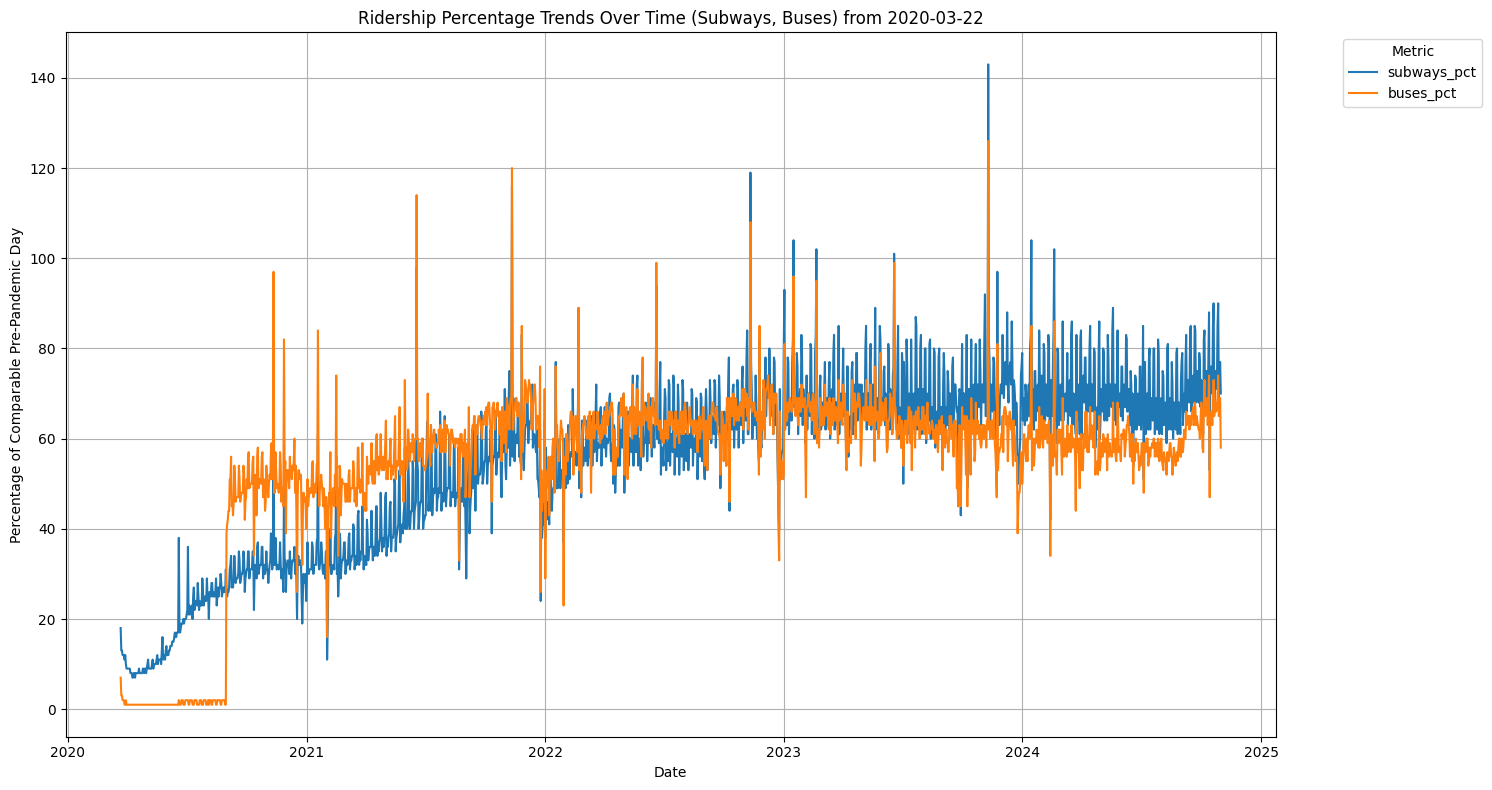

In [ ]:
# Set the figure size for better readability
plt.figure(figsize=(15, 8))

# Create a line plot showing ridership percentage trends over time
# - 'date' on the x-axis
# - 'value' (ridership percentage) on the y-axis
# - 'metric' determines the color of each line (Subways, Buses, LIRR)
sns.lineplot(data=df_filtered_plot, x='date', y='value', hue='metric')

# Add a descriptive title
plt.title('Ridership Percentage Trends Over Time (Subways, Buses) from 2020-03-22')

# Label the x-axis
plt.xlabel('Date')

# Label the y-axis
plt.ylabel('Percentage of Comparable Pre-Pandemic Day')

# Place the legend outside the plot area to avoid overlapping lines
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add gridlines to make trends easier to compare
plt.grid(True)

# Adjust layout to prevent clipping of labels or legend
plt.tight_layout()

# Display the plot
plt.show()

Insight: This plot allows us to observe pandemic-related dips and recovery trends for major transport modes.

In [ ]:
# Define the columns that represent recovery percentages for each transport mode
recovery_cols = [
    'subways_pct',
    'buses_pct',
    'lirr_pct',
    'metro_north_pct',
    'access_ride_pct',
    'staten_pct'
]

# Create a new DataFrame with only the 'date' column and the recovery percentage columns
# This simplifies analysis focused on ridership recovery trends
df_recovery = df[['date'] + recovery_cols]

In [ ]:
# Ensure that the 'date' column is in datetime format
# This is necessary for time-based operations like grouping by quarter or plotting over time
df['date'] = pd.to_datetime(df['date'])

## 3.2 Ridership Recovery Trends by Transport Mode

**Business Question:** Which transport modes recovered fastest post-pandemic?


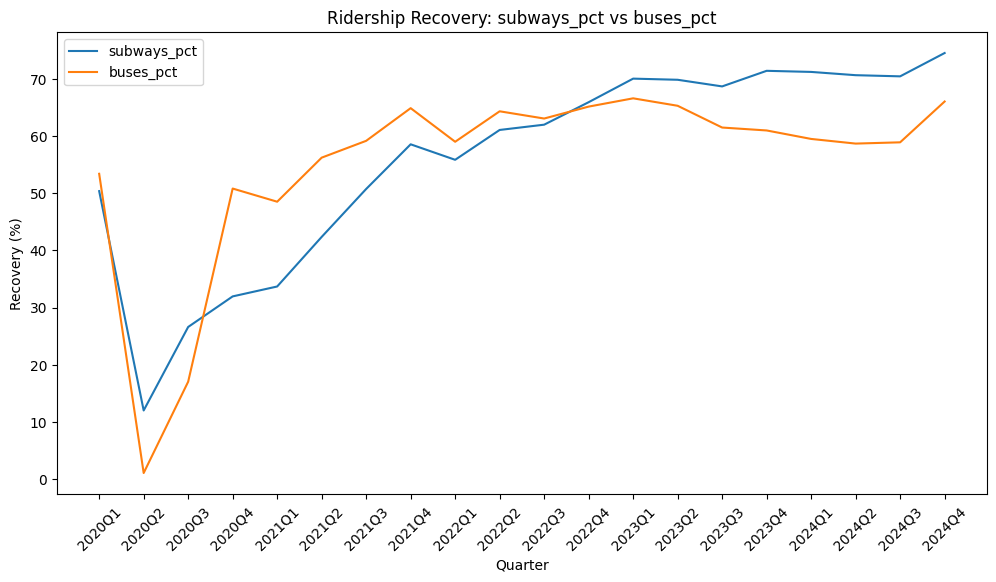

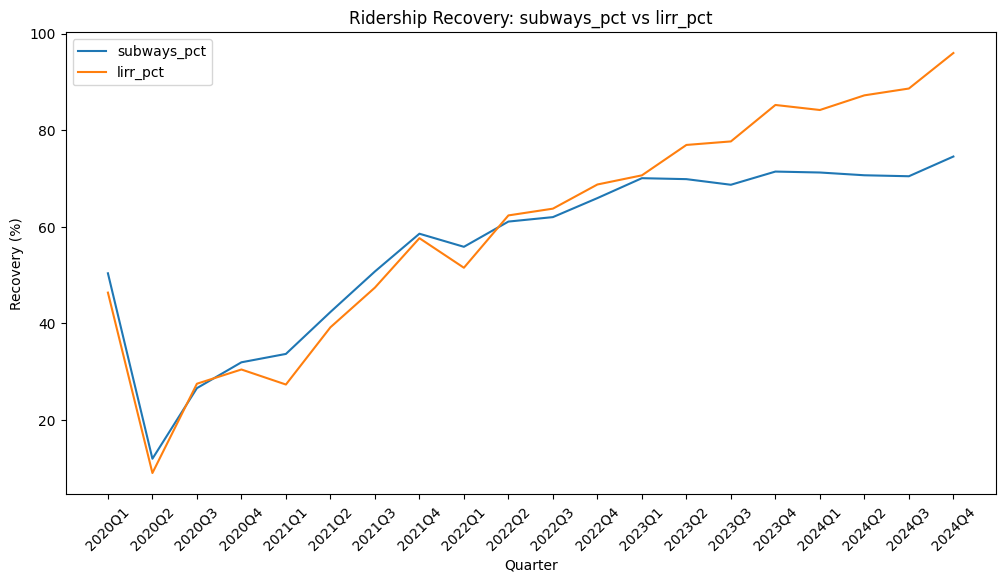

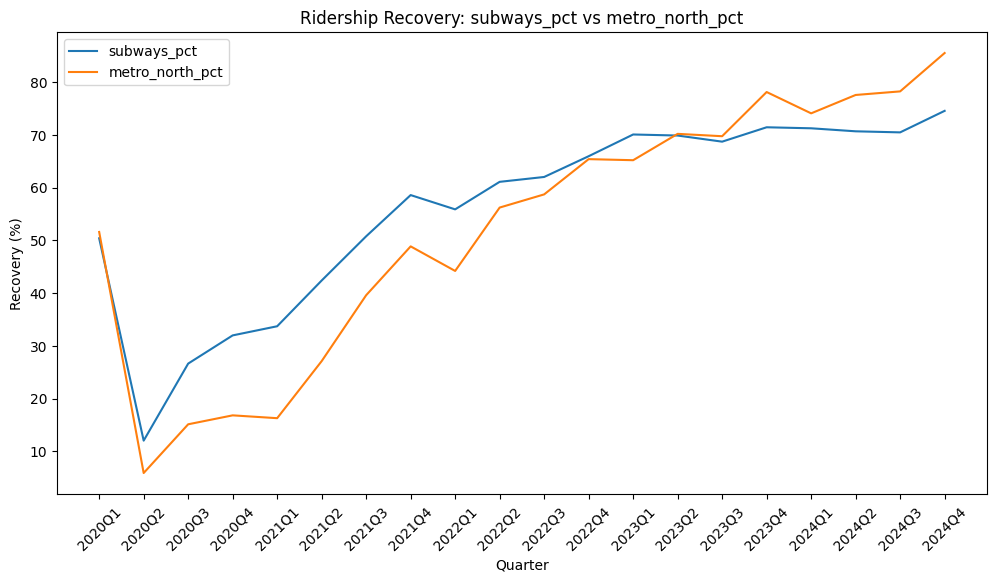

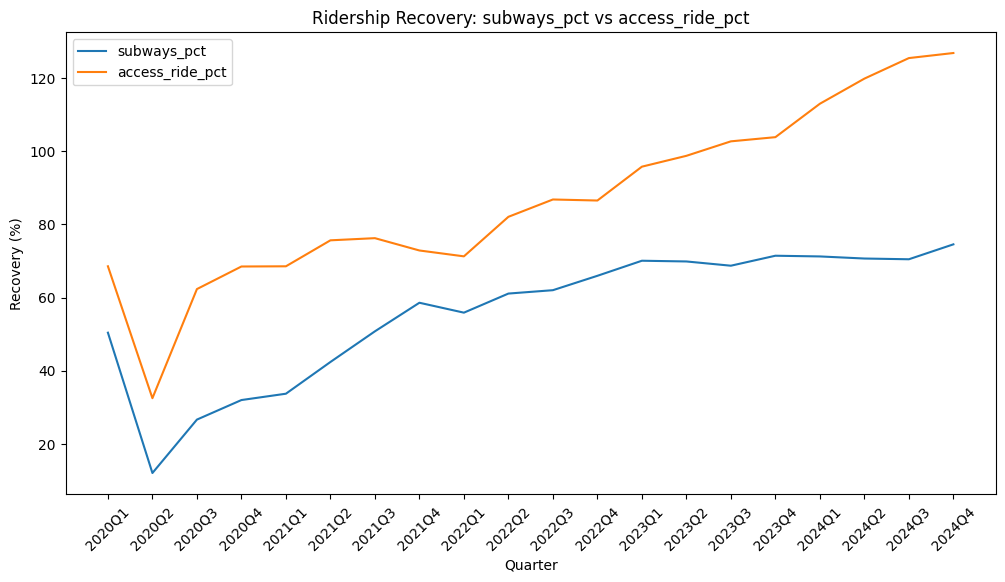

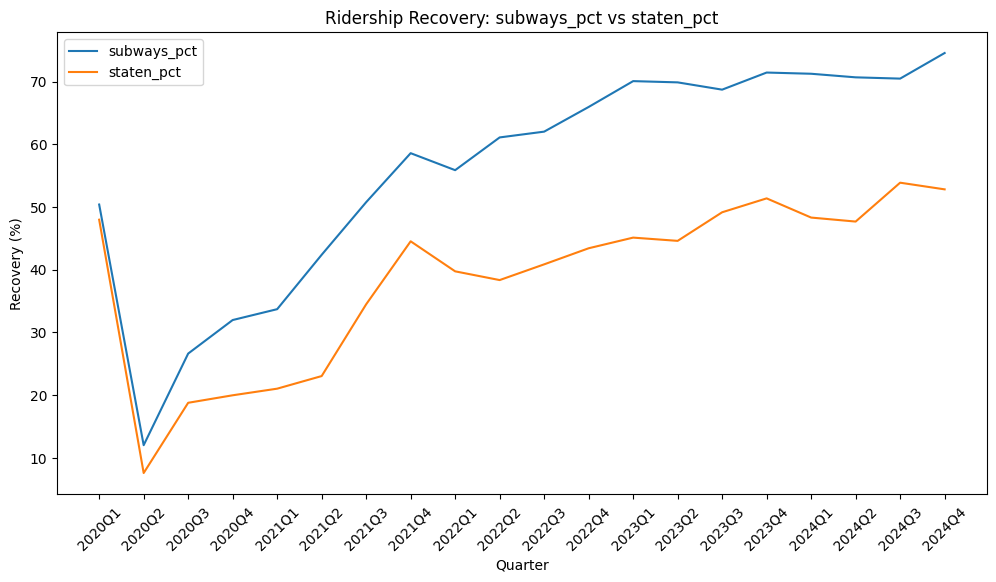

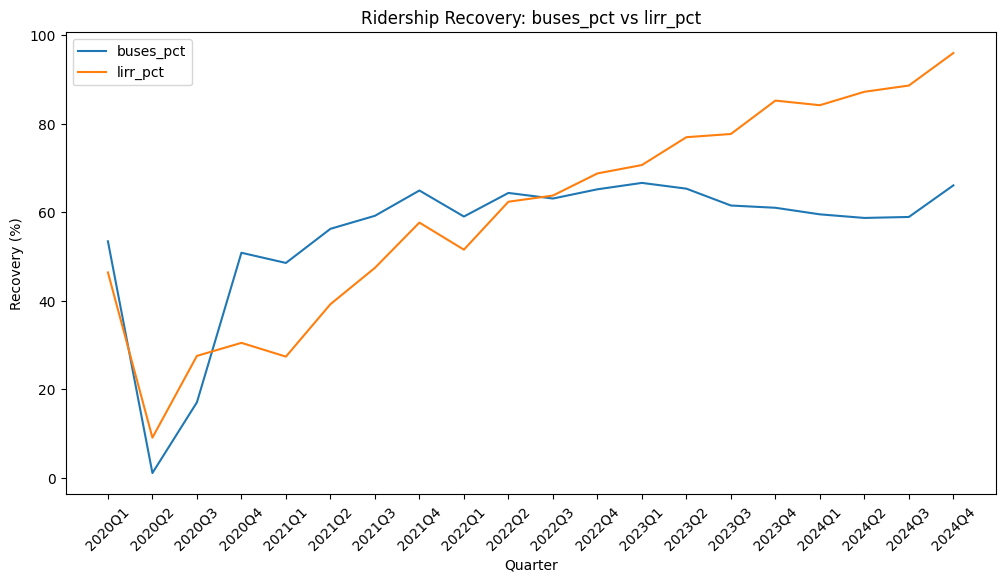

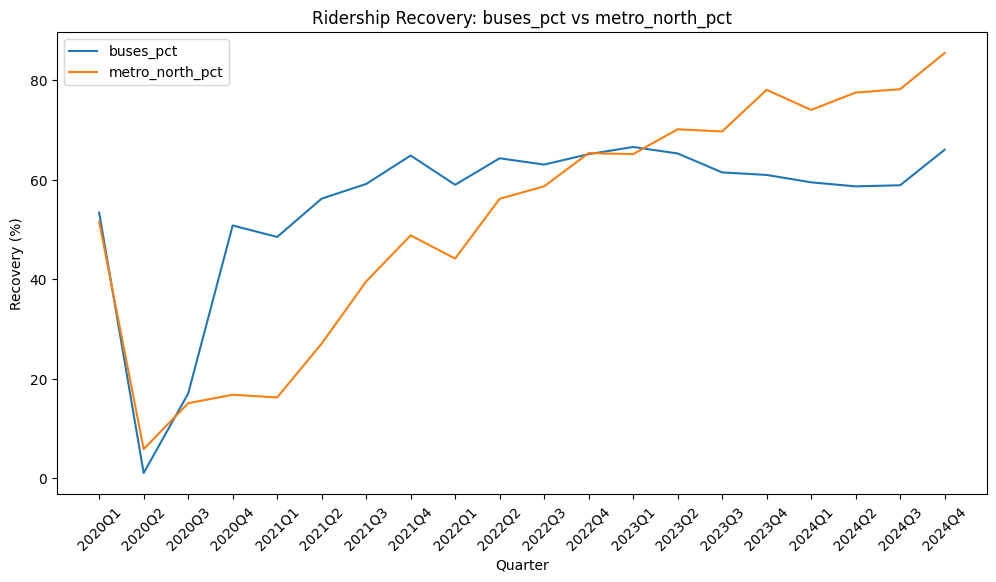

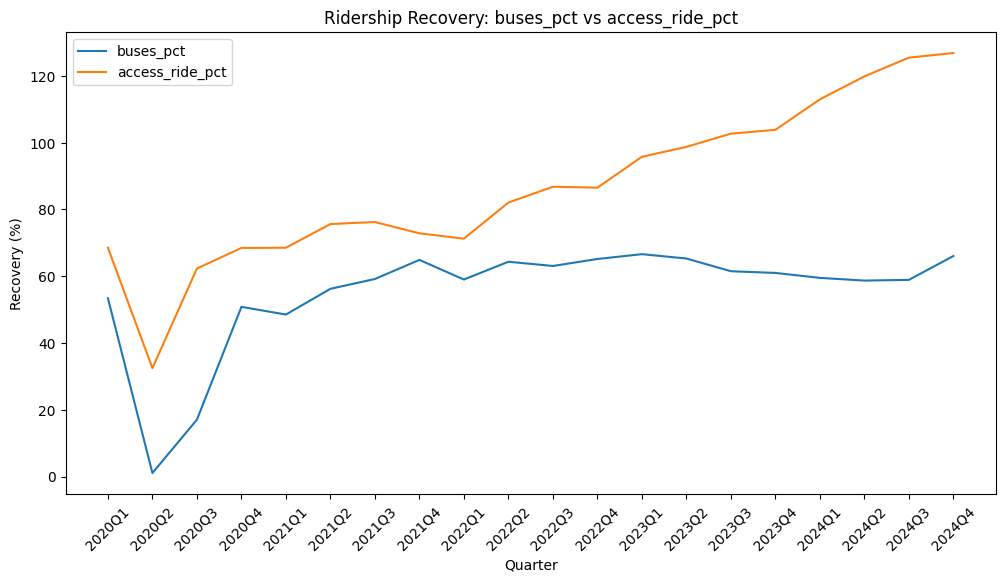

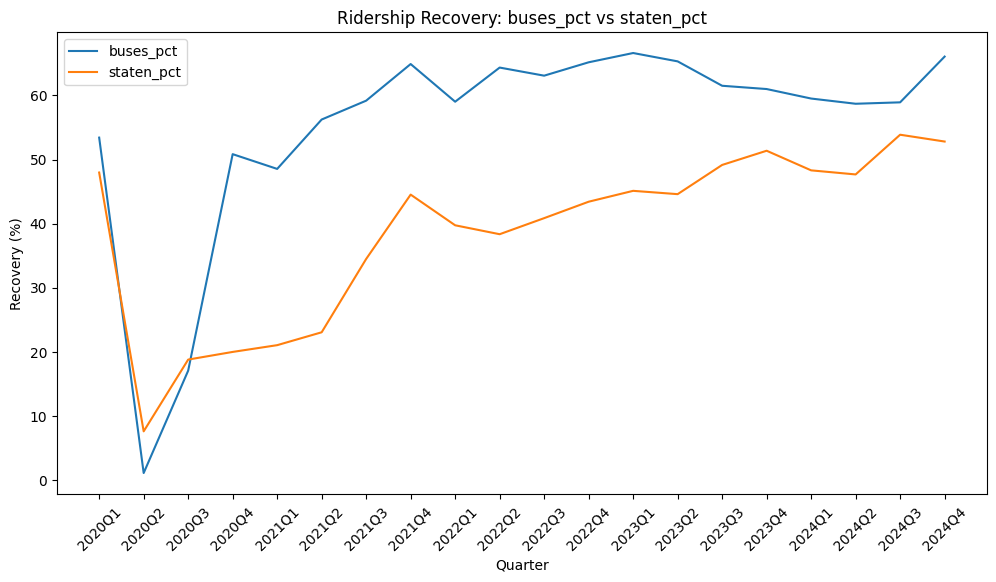

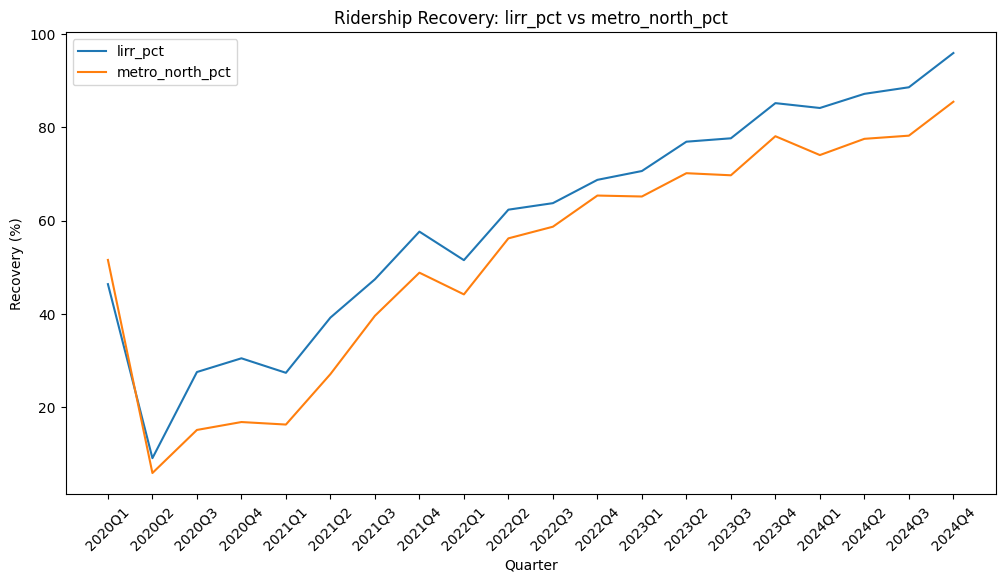

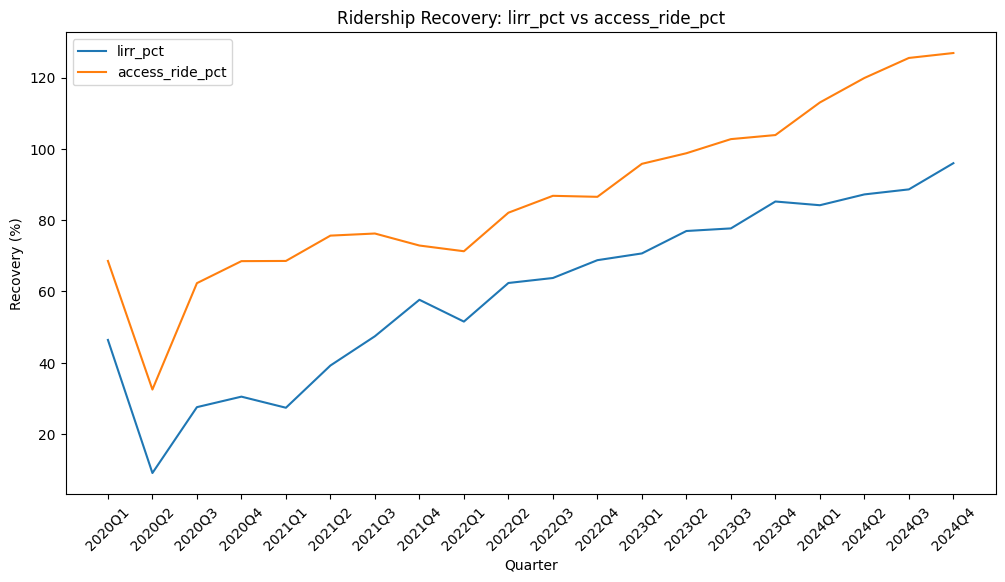

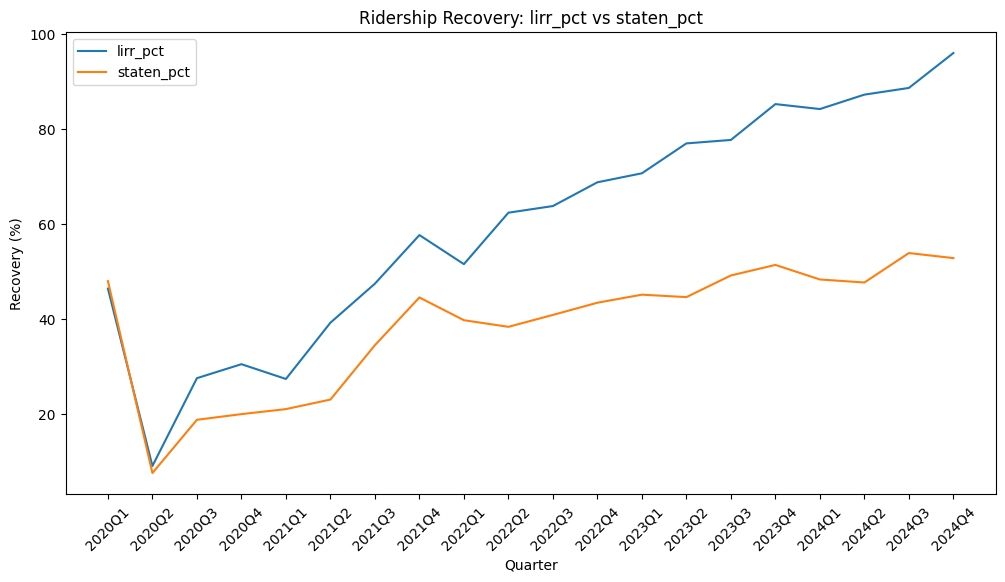

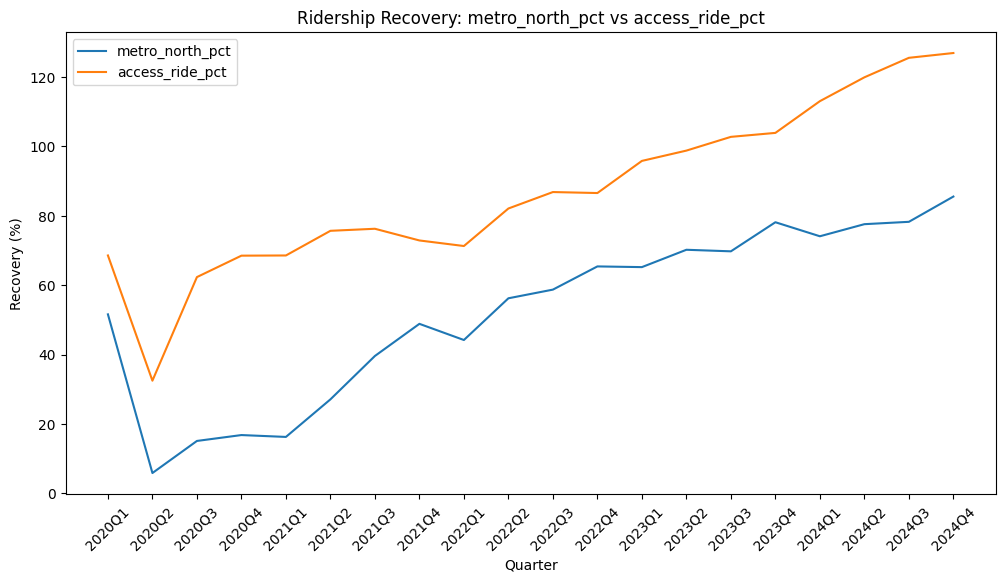

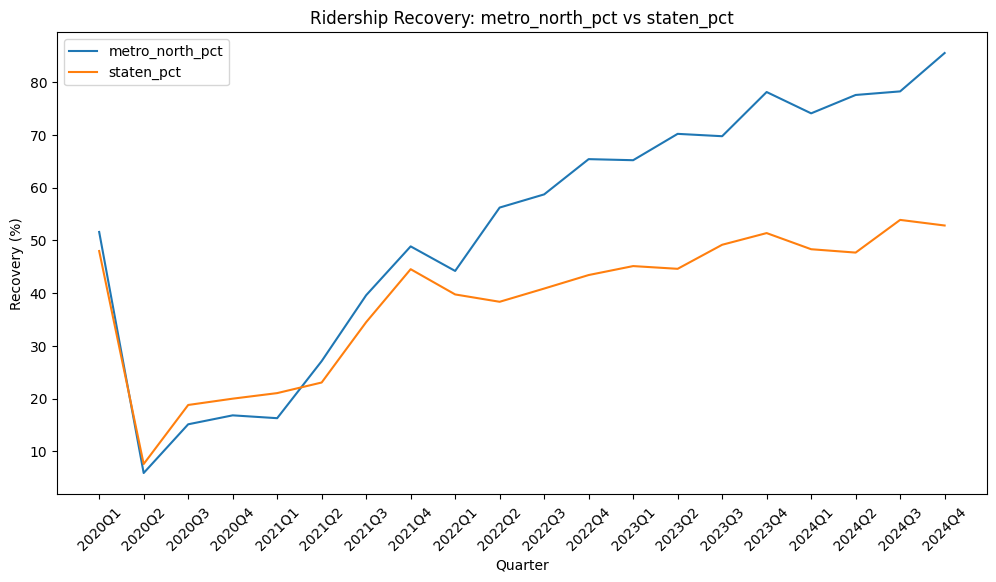

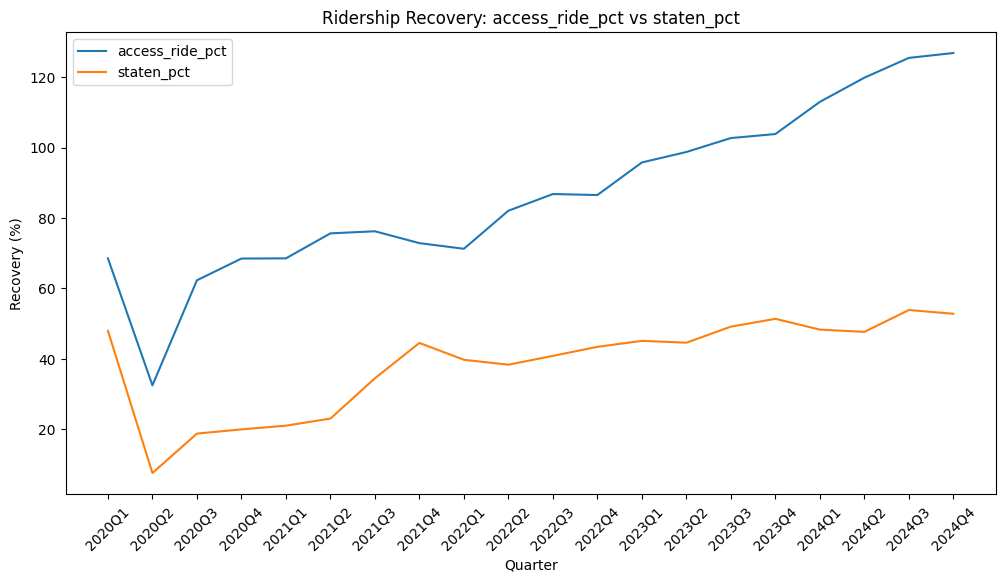

In [ ]:
import itertools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert 'date' column to quarterly periods (e.g., 2023Q1)
df['Quarter'] = df['date'].dt.to_period('Q')

# Group the DataFrame by quarter and calculate the mean recovery for the selected columns
quarterly_df = df.groupby('Quarter')[recovery_cols].mean().reset_index()

# Sort the DataFrame by 'Quarter' to ensure chronological order
quarterly_df = quarterly_df.sort_values('Quarter')

# Iterate over all possible pairs of recovery columns for comparison
for col1, col2 in itertools.combinations(recovery_cols, 2):

    # Create a new figure for each pair
    plt.figure(figsize=(12,6))

    # Plot the first recovery mode
    plt.plot(quarterly_df['Quarter'].astype(str), quarterly_df[col1], label=col1)

    # Plot the second recovery mode
    plt.plot(quarterly_df['Quarter'].astype(str), quarterly_df[col2], label=col2)

    # Set the plot title
    plt.title(f'Ridership Recovery: {col1} vs {col2}')

    # Label x-axis and y-axis
    plt.xlabel('Quarter')
    plt.ylabel('Recovery (%)')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45)

    # Add a legend to distinguish the two lines
    plt.legend()

    # Display the plot
    plt.show()

Insight: Pairwise comparison highlights which modes recovered faster or slower in each quarter.

## 3.3 Top Transport Modes by Average Ridership

**Business Question:** Which transport modes have the highest overall ridership?

In [ ]:
# Select all columns that contain '_total' in their name, but exclude 'bridges_total'
# This ensures we only include actual transport ridership columns
total_cols = [col for col in df.columns if '_total' in col and col != 'bridges_total']

# Calculate the average ridership for each selected transport mode
# - The result is a Series with column names as index and average values as data
# - Sort in descending order to see the highest average ridership at the top
avg_ridership = df[total_cols].mean().sort_values(ascending=False)

# Display the top 3 transport modes with the highest average ridership
avg_ridership.head(3)

,0
subways_total,2.509055e+06
buses_total,1.006868e+06
lirr_total,1.359601e+05


In [ ]:
# Get the names of the top 3 transportation modes based on average ridership
# - avg_ridership is assumed to be a Series sorted by average ridership
top3_modes = avg_ridership.head(3).index.tolist()

# Print the top 3 modes to verify the selection
print("Top 3 ridership modes:", top3_modes)

Top 3 ridership modes: ['subways_total', 'buses_total', 'lirr_total']


Insight: Identifies the most critical transport modes for business planning and resource allocation.

## 3.4 Quarterly Average Total Ridership for Top 3 Modes

**Business Question:** How did the top transport modes trend on a quarterly basis?

In [ ]:
# Create a new DataFrame with only the 'date' column and the top 3 ridership modes
df_top3 = df[['date'] + top3_modes].copy()

# Add a 'Quarter' column by converting the 'date' to quarterly periods (e.g., 2023Q1)
df_top3['Quarter'] = df_top3['date'].dt.to_period('Q')

# Group by 'Quarter' and calculate the mean ridership for each of the top 3 modes
quarterly_top3_df = df_top3.groupby('Quarter')[top3_modes].mean().reset_index()

# Sort the DataFrame by 'Quarter' so that it is in chronological order
quarterly_top3_df = quarterly_top3_df.sort_values('Quarter')

# Display the first few rows to verify the result
print(quarterly_top3_df.head())

  Quarter  subways_total   buses_total     lirr_total
0  2020Q1   2.375007e+06  1.028122e+06  116942.709677
1  2020Q2   5.597212e+05  1.692959e+04   21053.802198
2  2020Q3   1.201057e+06  3.315686e+05   64398.771739
3  2020Q4   1.467823e+06  9.072936e+05   69031.706522
4  2021Q1   1.455494e+06  8.623524e+05   59325.300000


In [ ]:
# Display the data types of all columns in the DataFrame
# This helps verify that the mode columns were successfully converted to numeric
quarterly_top3_df.dtypes

,0
Quarter,period[Q-DEC]
subways_total,float64
buses_total,float64
lirr_total,float64


In [ ]:
# Assume that all columns except 'Quarter' represent transportation modes
modes_cols = quarterly_top3_df.columns.drop('Quarter')

# Convert all mode columns to numeric type
# - This ensures any non-numeric values (like strings) are coerced to NaN
# - Necessary for calculations, plotting, and aggregations
quarterly_top3_df[modes_cols] = quarterly_top3_df[modes_cols].apply(pd.to_numeric, errors='coerce')

## 3.5 Line Plot: Quarterly Average Total Ridership

  Quarter           mode     ridership
0  2020Q1  subways_total  2.375007e+06
1  2020Q2  subways_total  5.597212e+05
2  2020Q3  subways_total  1.201057e+06
3  2020Q4  subways_total  1.467823e+06
4  2021Q1  subways_total  1.455494e+06
Quarter      period[Q-DEC]
mode                object
ridership          float64
dtype: object
  Quarter           mode     ridership
0  2020Q1  subways_total  2.375007e+06
1  2020Q2  subways_total  5.597212e+05
2  2020Q3  subways_total  1.201057e+06
3  2020Q4  subways_total  1.467823e+06
4  2021Q1  subways_total  1.455494e+06
Quarter       object
mode          object
ridership    float64
dtype: object


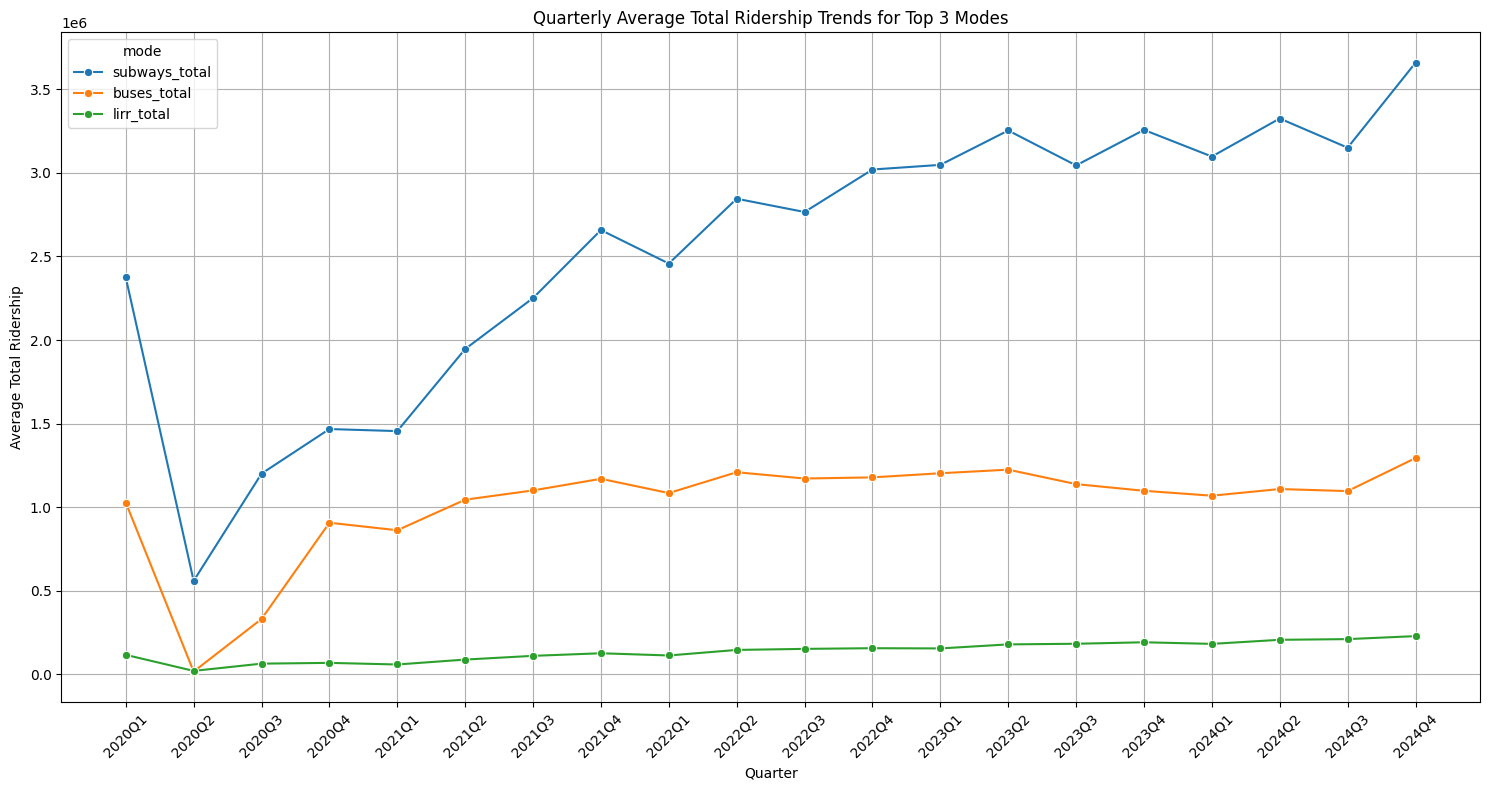

In [ ]:
# Melt the quarterly_top3_df DataFrame from wide to long format
# - 'Quarter' stays as the identifier column
# - The top 3 ridership columns become one column called 'mode'
# - The corresponding ridership values go into a new column called 'ridership'
melted_df = pd.melt(
    quarterly_top3_df,
    id_vars='Quarter',
    var_name='mode',        # New column storing the name of the transportation mode
    value_name='ridership'  # New column storing the corresponding ridership value
)

# Check the first few rows and data types to ensure melting worked correctly
print(melted_df.head())
print(melted_df.dtypes)

# Convert 'Quarter' from period type (period[Q-DEC]) to string
# This ensures proper labeling on the x-axis when plotting
melted_df['Quarter'] = melted_df['Quarter'].astype(str)

# Verify the conversion
print(melted_df.head())
print(melted_df.dtypes)

# Create a line plot to show trends over quarters
plt.figure(figsize=(15, 8))  # Set figure size for better readability

sns.lineplot(
    data=melted_df,
    x='Quarter',          # X-axis: Quarter in string format
    y='ridership',        # Y-axis: Average total ridership
    hue='mode',           # Color line by transportation mode
    marker='o'            # Add markers for each quarter point
)

# Add title and axis labels
plt.title('Quarterly Average Total Ridership Trends for Top 3 Modes')
plt.xlabel('Quarter')
plt.ylabel('Average Total Ridership')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add gridlines to make comparison easier
plt.grid(True)

# Adjust layout to prevent clipping of labels or title
plt.tight_layout()

# Display the plot
plt.show()

Insight: Displays growth or decline trends in top-performing modes over time.

## 3.6 Classify Day Types: Weekday, Weekend, Holiday

**Business Question:** How do ridership patterns differ by day type?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.tseries.holiday import USFederalHolidayCalendar

# -----------------------------
# 3. Identify weekends
# Weekday numbers: Monday=0, Sunday=6
# Any day with weekday >= 5 is Saturday or Sunday
# -----------------------------
df['date'] = pd.to_datetime(df['date'])  # Ensure 'date' column is in datetime format
df['is_weekend'] = df['date'].dt.weekday >= 5  # True for Saturday/Sunday, False otherwise

# Count the total number of weekend days in the dataset
weekend_count = df['is_weekend'].sum()

# -----------------------------
# 4. Identify US Federal Holidays
# -----------------------------
cal = USFederalHolidayCalendar()  # Create a calendar object for US federal holidays

# Get all holidays within the dataset's date range
holidays = cal.holidays(start=df['date'].min(), end=df['date'].max())

# Create a boolean column indicating whether each date is a holiday
df['is_holiday'] = df['date'].isin(holidays)

# Count the total number of holidays in the dataset
holiday_count = df['is_holiday'].sum()

# -----------------------------
# 5. Create Day_Type column
# Priority: Holiday > Weekend > Weekday
# -----------------------------
def classify_day(row):
    if row['is_holiday']:
        return 'Holiday'      # Highest priority
    elif row['is_weekend']:
        return 'Weekend'      # Second priority
    else:
        return 'Weekday'      # All other days

# Apply the function to each row to create the 'Day_Type' column
df['Day_Type'] = df.apply(classify_day, axis=1)

# -----------------------------
# 6. Print results
# -----------------------------
print("Weekends:", weekend_count)  # Total weekends
print("Holidays:", holiday_count)  # Total holidays

Weekends: 487
Holidays: 48


Insight: Categorizes days for analyzing ridership differences on working vs non-working days.

## 3.7 Distribution of Day Types



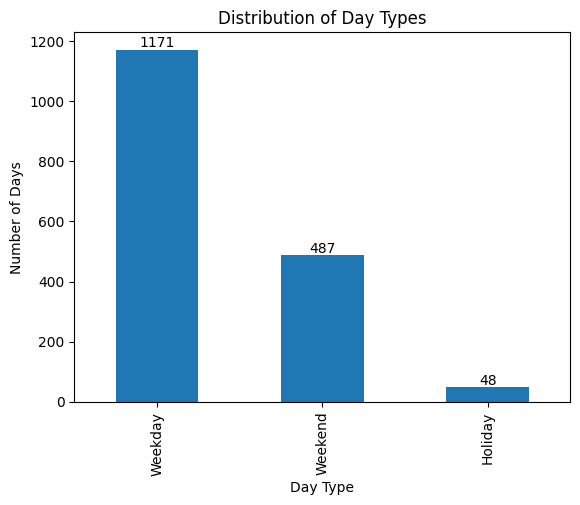

In [ ]:
# Count the number of occurrences for each day type
day_counts = df['Day_Type'].value_counts()

# Create a new figure for the plot
plt.figure()

# Plot a bar chart of the counts of each day type
day_counts.plot(kind='bar')

# Set the title of the chart
plt.title('Distribution of Day Types')

# Label the x-axis
plt.xlabel('Day Type')

# Label the y-axis
plt.ylabel('Number of Days')

# Display the actual count values on top of each bar
for i, v in enumerate(day_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Show the chart
plt.show()

Insight: Visualizes the frequency of weekdays, weekends, and holidays in the dataset.

## 3.8 Ridership Comparison: Day Off vs Working Day

**Business Question:** How does ridership vary between working days and days off?

In [ ]:
# Create a new column 'Day_Off' which is True if the day is a weekend or a holiday
df['Day_Off'] = df['is_weekend'] | df['is_holiday']

# Convert the boolean values into readable labels for easier interpretation
# True → 'Day Off', False → 'Working Day'
df['Day_Type_Final'] = df['Day_Off'].map({
    True: 'Day Off',
    False: 'Working Day'
})

In [ ]:
# Define the list of columns representing total ridership for each transport type
columns = [
    'subways_total',
    'buses_total',
    'lirr_total',
    'metro_north_total',
    'access_ride_total',
    'staten_total'
]

# Group the data by day type (Weekend vs Weekday) and calculate the total ridership per transport type
ridership_comparison = df.groupby('Day_Type_Final')[columns].sum()

# Print the resulting DataFrame showing total ridership for each transport type by day type
print(ridership_comparison)

                subways_total  buses_total  lirr_total  metro_north_total  \
Day_Type_Final                                                              
Day Off             904102250    348919674    43322819           38152385   
Working Day        3376345545   1368797292   188625139          157847009   

                access_ride_total  staten_total  
Day_Type_Final                                   
Day Off                   7788973        863520  
Working Day              29643282       6692960  


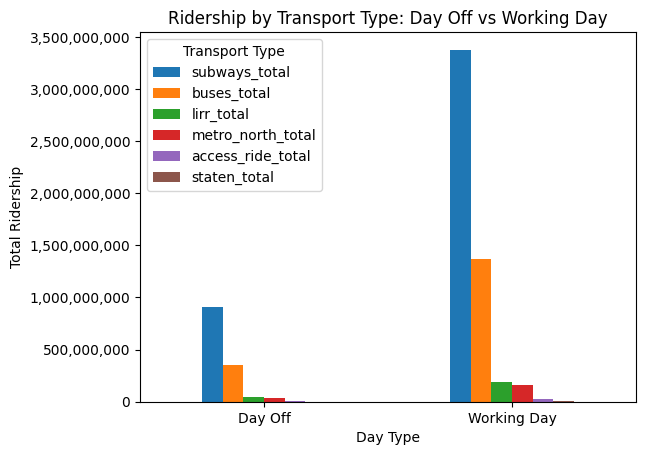

In [ ]:
import matplotlib.ticker as mtick

# Create a bar chart comparing total ridership by transport type for each day type
ax = ridership_comparison.plot(kind='bar')

# Set the chart title
ax.set_title('Ridership by Transport Type: Day Off vs Working Day')

# Label the x-axis (Day Type)
ax.set_xlabel('Day Type')

# Label the y-axis (Total Ridership)
ax.set_ylabel('Total Ridership')

# Keep x-axis labels horizontal (no rotation)
ax.tick_params(axis='x', rotation=0)

# Add a legend showing which bar corresponds to each transport type
ax.legend(title='Transport Type')

# Format the y-axis numbers to display full numbers instead of scientific notation
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Display the chart
plt.show()

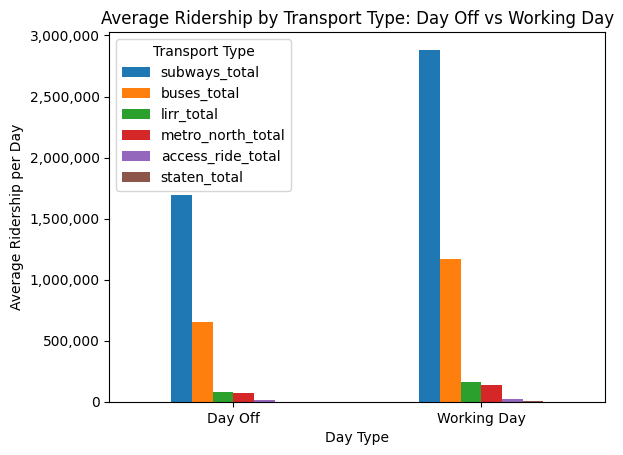

In [ ]:
# Calculate the average ridership for each transport type grouped by day type (Weekend vs Weekday)
ridership_avg = df.groupby('Day_Type_Final')[columns].mean()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create a bar chart of average ridership by transport type
ax = ridership_avg.plot(kind='bar')

# Set the title of the chart
ax.set_title('Average Ridership by Transport Type: Day Off vs Working Day')

# Label the x-axis (Day Type)
ax.set_xlabel('Day Type')

# Label the y-axis (Average Ridership per Day)
ax.set_ylabel('Average Ridership per Day')

# Keep the x-axis labels horizontal (no rotation)
ax.tick_params(axis='x', rotation=0)

# Add a legend showing which bar corresponds to each transport type
ax.legend(title='Transport Type')

# Format the y-axis numbers to show full numbers instead of scientific notation
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Display the plot
plt.show()

Insight: Highlights differences in usage patterns between working days and days off for all transport modes.